# FIN5016 Assessment 1B
# Credit Risk Model for loan approval

This notebook develops a machine learning model to classify credit risk using historical U.S. Small Business Administration (SBA) loan data. The goal is to predict whether a loan is likely to be repaid or defaulted, in order to support the loan approval process.

The main dataset contains small business loan records, and an additional state-level unemployment dataset is used to strengthen the analysis with macroeconomic information. Although this dataset relates to business lending rather than personal lending, it is still suitable because it **addresses the same core assignment problem ->** **predicting whether a loan applicant is likely to default or repay.**

The target variable is created from `MIS_Status`, where:
- `P I F` = repaid
- `CHGOFF` = defaulted

This notebook contains the following assignment stages:
- Data processing,
- Exploratory data analysis,
- Feature engineering,
- Model development and evaluation,
- Interpretation and reporting.

**Sources:**
1.  **SBA National Dataset:** Historical records of 890k+ loans: [![Dataset](https://img.shields.io/badge/Data-SBA%20National-orange)](https://www.kaggle.com/datasets/mirbektoktogaraev/should-this-loan-be-approved-or-denied/data)
2.  **FRED Macroeconomic Data:** Monthly state-level unemployment rates: [![Dataset](https://img.shields.io/badge/Data-FRED%20MacroData-orange)](https://fred.stlouisfed.org/release/tables?rid=112&eid=1195039)

**Project available at:**

[![GitHub Repository](https://img.shields.io/badge/GitHub-Repository-blue?logo=github)](https://github.com/AvanthaD98/fintech_loan-risk_model)

## PHASE 1: DATA PROCESSING

In [196]:
# =============================
# STEP 1.1: DATA INGESTION
# =============================
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')

print("Loading datasets...") # Loading the CSV files (Merging and loading the data files which has been split previosly due to file handling purposes)
part1 = pd.read_csv('SBAnational_part1.csv', low_memory=False)
part2 = pd.read_csv('SBAnational_part2.csv', low_memory=False)
part3 = pd.read_csv('SBAnational_part3.csv', low_memory=False)
part4 = pd.read_csv('SBAnational_part4.csv', low_memory=False)

df_base = pd.concat([part1, part2, part3, part4], ignore_index=True) #Combine all four parts into one master dataframe
del part1, part2, part3, part4
gc.collect()
print(f"Base Dataset Loaded: {df_base.shape}")

Loading datasets...
Base Dataset Loaded: (899164, 27)


In [197]:
# ====================================================================
# STEP 1.2: MACROECONOMIC MERGING (Time-Aware)
# ====================================================================
print("Merging macroeconomic data by exact State, Year, and Month...")

df_macro_raw = pd.read_csv('state_unemployment.csv')
date_col = df_macro_raw.columns[0] 

# Convert the FRED unemployment dataset from wide to long format to merge with the SBA dataset by State and approval time
df_macro_long = df_macro_raw.melt(id_vars=[date_col], var_name='State', value_name='Unemployment_Rate')
df_macro_long['FRED_Date'] = pd.to_datetime(df_macro_long[date_col], errors='coerce')

# Extract year and month so the merge reflects economic conditions at the time the loan was approved
df_macro_long['ApprovalYear'] = df_macro_long['FRED_Date'].dt.year
df_macro_long['ApprovalMonth'] = df_macro_long['FRED_Date'].dt.month

df_macro_clean = df_macro_long[['State', 'ApprovalYear', 'ApprovalMonth', 'Unemployment_Rate']].dropna()

df_base['ApprovalDate'] = pd.to_datetime(df_base['ApprovalDate'], errors='coerce')
df_base['ApprovalYear'] = df_base['ApprovalDate'].dt.year
df_base['ApprovalMonth'] = df_base['ApprovalDate'].dt.month

df = pd.merge(df_base, df_macro_clean, on=['State', 'ApprovalYear', 'ApprovalMonth'], how='left')
print(f"Merged Dataset Shape: {df.shape}")

Merging macroeconomic data by exact State, Year, and Month...
Merged Dataset Shape: (899164, 30)


In [198]:
# =============================================================
# STEP 1.3: DATA SANITIZATION & LEAKAGE PREVENTION
# =============================================================
# Map Target Variable
# 1 = charged off (defaulted)
# 0 = paid in full (repaid)
df = df.dropna(subset=['MIS_Status'])
df['Default'] = df['MIS_Status'].map({'CHGOFF': 1, 'P I F': 0})
df = df.drop(columns=['MIS_Status'])

# Clean Currency Strings
currency_cols = ['DisbursementGross', 'GrAppv', 'SBA_Appv']
for col in currency_cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

# Drop Identifiers & Prevent Leakage to support approval time prediction
cols_to_drop = [
    'LoanNr_ChkDgt', 'Name', # Identifiers
    'City', 'Zip', 'Bank',   # High-cardinality (Overfitting risk)
    'ChgOffDate', 'ChgOffPrinGr', 'BalanceGross', 'DisbursementDate', # Target & Temporal Leakage
    'ApprovalDate'           # Redundant now
]
df = df.drop(columns=cols_to_drop, errors='ignore')
print("Leakage columns and identifiers dropped successfully.")

Leakage columns and identifiers dropped successfully.


In [199]:
# ====================================================================================
# STEP 1.4: IMPUTATION & OUTLIER HANDLING (Isolates the Imputation and Winsorization)
# ====================================================================================
from sklearn.impute import SimpleImputer

# Median imputation is used for numeric features because it is more robust to outliers
num_imputer = SimpleImputer(strategy='median')
# Constant imputation is used for categorical variables to preserve missing category information
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

# Separate the dataset into numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Default')
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Apply median imputation to numeric columns and constant-value imputation to categorical columns
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Winsorization (Clip top and bottom 1%)
for col in numeric_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print(f"Imputation & Outlier Capping Complete. Missing Values: {df.isnull().sum().max()}")

Imputation & Outlier Capping Complete. Missing Values: 0


## PHASE 2: EXPLORATORY DATA ANALYSIS

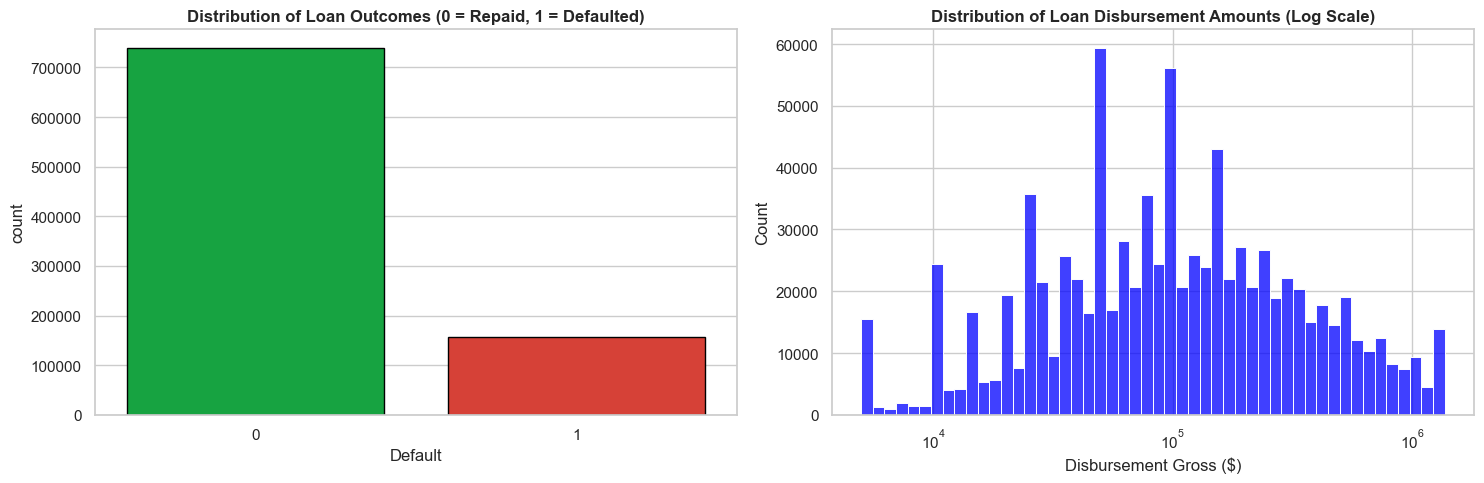

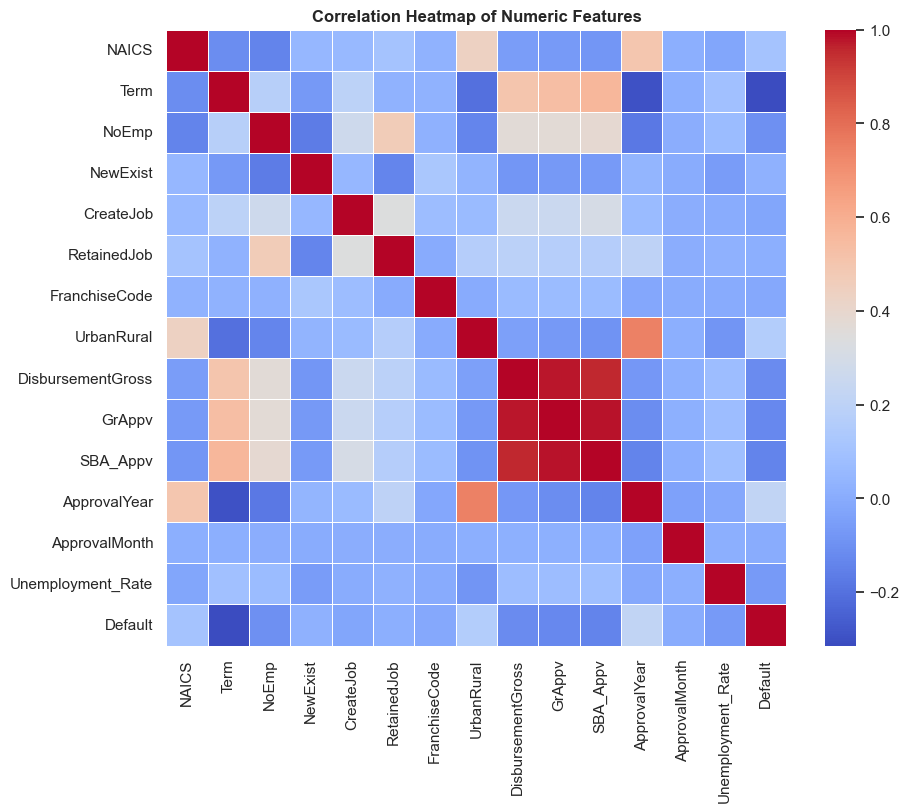

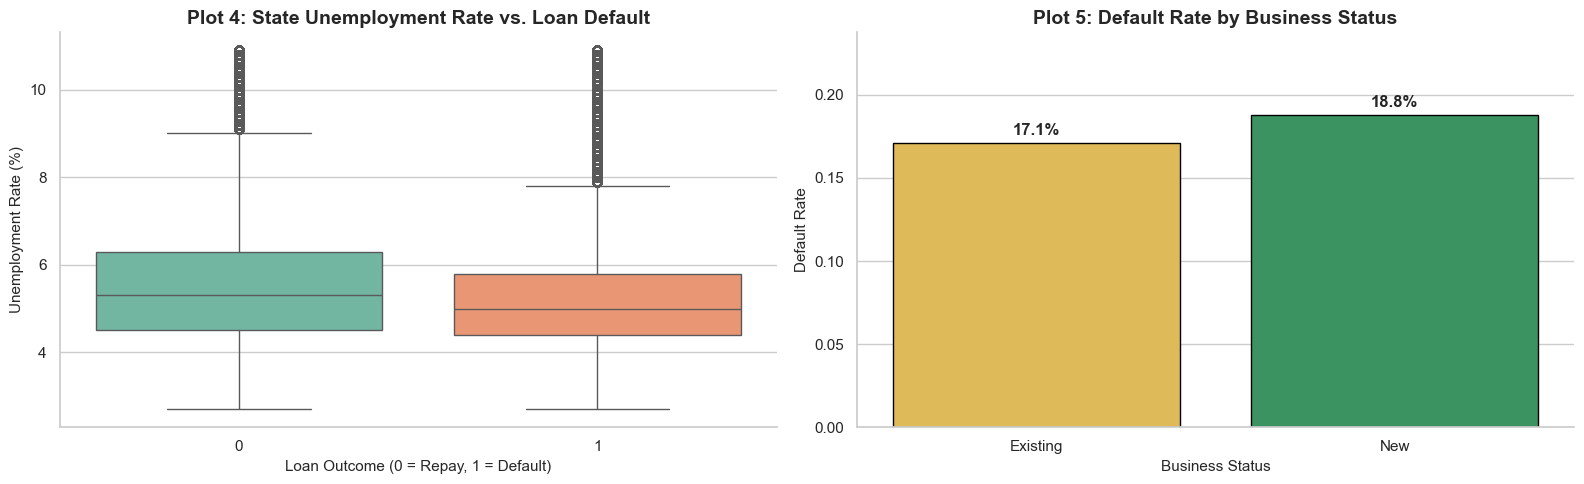

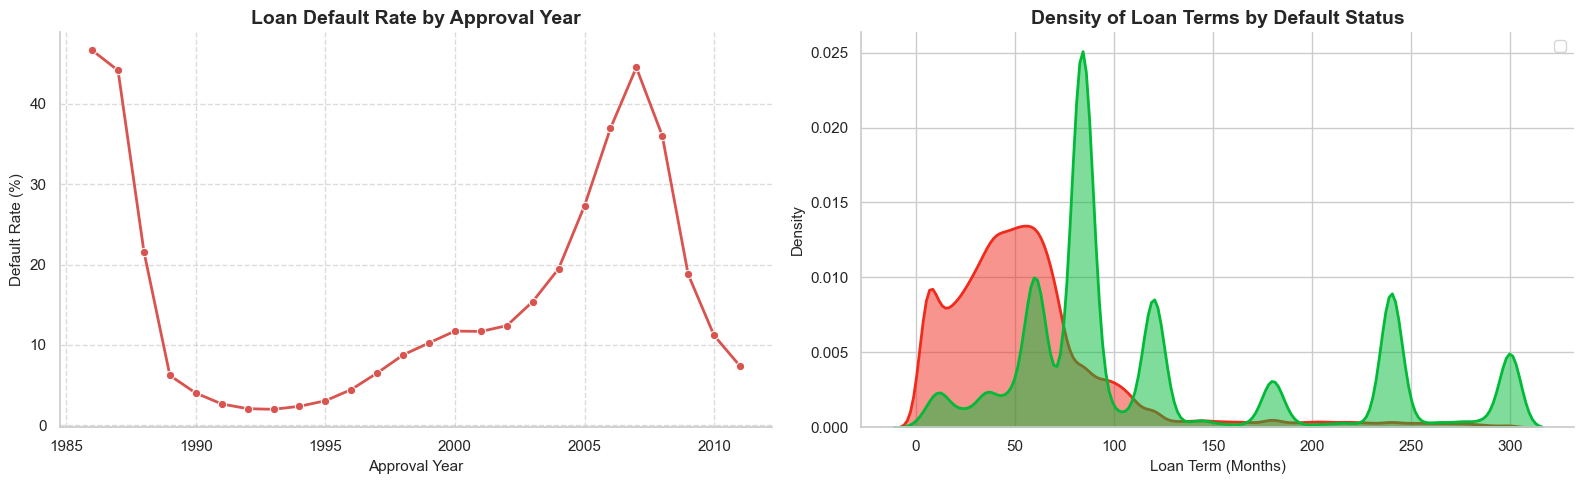

In [200]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid") # Set the visual style using seaborn
plt.figure(figsize=(15, 5))

# Plot 1: Target Variable Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Default', palette=['#00ba38', "#f12a1c"], edgecolor='black')
plt.title('Distribution of Loan Outcomes (0 = Repaid, 1 = Defaulted)', fontweight="bold")

# Plot 2: Distribution of Loan Sizes (Log scale for outliers)
plt.subplot(1, 2, 2)
sns.histplot(df['DisbursementGross'], bins=50, log_scale=True, color='blue')
plt.title('Distribution of Loan Disbursement Amounts (Log Scale)', fontweight="bold")
plt.xlabel('Disbursement Gross ($)')
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontweight="bold")
plt.show()

# Plot 4: Macroeconomic Impact (Box Plot) - side-by-side view
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Default', y='Unemployment_Rate', palette='Set2')
plt.title("Plot 4: State Unemployment Rate vs. Loan Default", fontsize=14, fontweight="bold")
plt.xlabel("Loan Outcome (0 = Repay, 1 = Default)", fontsize=11)
plt.ylabel("Unemployment Rate (%)", fontsize=11)

# Plot 5: Business Age Risk (Bar Chart)

default_by_newexist = df[df["NewExist"].isin([1.0, 2.0])].groupby("NewExist")["Default"].mean().reset_index()
default_by_newexist["BusinessStatus"] = default_by_newexist["NewExist"].map({1.0: "Existing", 2.0: "New"})

plt.subplot(1, 2, 2)
ax = sns.barplot(data=default_by_newexist, x="BusinessStatus", y="Default", palette=["#f4c542", "#2ca25f"], 
     edgecolor='black')

plt.title("Plot 5: Default Rate by Business Status", fontsize=14, fontweight="bold")
plt.xlabel("Business Status", fontsize=11)
plt.ylabel("Default Rate", fontsize=11)
plt.ylim(0, default_by_newexist["Default"].max() + 0.05)

for i, v in enumerate(default_by_newexist["Default"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()

# Plot 6: Macroeconomic Impact (Line Chart)
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
yearly_default = df.groupby('ApprovalYear')['Default'].mean() * 100
sns.lineplot(x=yearly_default.index, y=yearly_default.values, marker='o', color='#d9534f', linewidth=2)

plt.title('Loan Default Rate by Approval Year', fontsize=14, fontweight='bold')
plt.xlabel('Approval Year', fontsize=11)
plt.ylabel('Default Rate (%)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 7: The "Separation of Power" (KDE Density Plot)
plt.subplot(1, 2, 2)
# common_norm=False ensures both curves are scaled to be visible, despite the class imbalance
sns.kdeplot(data=df, x='Term', hue='Default', fill=True, common_norm=False, 
            palette=['#00ba38', "#f12a1c"], alpha=0.5, linewidth=2)

plt.title('Density of Loan Terms by Default Status', fontsize=14, fontweight='bold')
plt.xlabel('Loan Term (Months)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(title=None) 

sns.despine()
plt.tight_layout()
plt.show()

## PHASE 3: FEATURE ENGINEERING

In [201]:
# ========================================================
# STEP 3.1: DOMAIN FEATURE CREATION
# ========================================================
df['Guarantee_Percentage'] = df['SBA_Appv'] / df['GrAppv']
df['Guarantee_Percentage'] = df['Guarantee_Percentage'].replace([np.inf, -np.inf], 0).fillna(0)
print("Guarantee_Percentage feature created successfully.")

Guarantee_Percentage feature created successfully.


In [202]:
# ===============================================
# STEP 3.2: ENCODING & NORMALIZATION
# ===============================================
from sklearn.preprocessing import StandardScaler

#Selected feature for the modelling
selected_features = ['Term', 'NoEmp', 'GrAppv', 'Guarantee_Percentage', 
                     'Unemployment_Rate', 'UrbanRural', 'RevLineCr', 'LowDoc',
                     'CreateJob', 'RetainedJob', 'NewExist']

X = df[selected_features]
y = df['Default']

# Encoding
categorical_cols = ['UrbanRural', 'RevLineCr', 'LowDoc']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Standardizing the numeric variables
scaler = StandardScaler()
numeric_cols = ['Term', 'NoEmp', 'GrAppv', 'Guarantee_Percentage', 'Unemployment_Rate', 
                'CreateJob', 'RetainedJob', 'NewExist']

# Create final feature matrix
X_final = X_encoded.copy()
X_final[numeric_cols] = scaler.fit_transform(X_final[numeric_cols])
print(f"Final Feature Matrix Ready. Shape: {X_final.shape}")

Final Feature Matrix Ready. Shape: (897167, 36)


## PHASE 4: MODEL DEVELOPMENT & EVALUATION

*A stratified sample of 50,000 observations was used for model training and tuning to keep computation efficient while strictly preserving the class distribution (Repay vs. Default) of the full dataset.*

In [203]:
# ==================================================
# STEP 4.1: TRAIN/TEST SPLIT & BASELINE MODEL
# ==================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Create a stratified sample of 50,000 observations to reduce computation time
X_sample, _, y_sample, _ = train_test_split(X_final, y, train_size=50000, stratify=y, random_state=42)
# Split the sample into Training and Testing sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.3, stratify=y_sample, random_state=42)

# Train Baseline
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [204]:
# ================================================================
# STEP 4.2: ENSEMBLE TUNING (RANDOM FOREST)
# ================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Base Random Forest model
print("Tuning Random Forest (Optimizing for Recall)...")
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {'n_estimators': [50, 100], 'max_depth': [10, 15]} # Test a few values for tree count and depth
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # Use stratified CV to keep class proportions balanced

# Tune the Random Forest using recall as the scoring metric (missing actual defaults > rejecting good loans)
rf_grid = GridSearchCV(rf_base, param_grid, cv=cv_strategy, scoring='recall')
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f"Best Random Forest Parameters: {rf_grid.best_params_}")

Tuning Random Forest (Optimizing for Recall)...
Best Random Forest Parameters: {'max_depth': 15, 'n_estimators': 50}


In [205]:
# =================================================================================================
# STEP 4.3: METRICS & COMPARISON
# =================================================================================================
# Compare models using accuracy, precision, recall, F1-score, and ROC-AUC 
# to capture both overall performance and default-detection ability

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    "Precision_Default": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    "Recall_Default": [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    "F1_Default": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    "ROC_AUC": [auc(fpr_lr, tpr_lr), auc(fpr_rf, tpr_rf)]
})

cols_to_round = ['Accuracy', 'Precision_Default', 'Recall_Default', 'F1_Default', 'ROC_AUC']
comparison[cols_to_round] = comparison[cols_to_round].round(4)

print("\n=== MODEL COMPARISON SUMMARY ===")
display(comparison)


=== MODEL COMPARISON SUMMARY ===


,Model,Accuracy,Precision_Default,Recall_Default,F1_Default,ROC_AUC
0,Logistic Regression,0.8410,0.6315,0.2270,0.3340,0.8350
1,Tuned Random Forest,0.9106,0.7943,0.6625,0.7224,0.9375


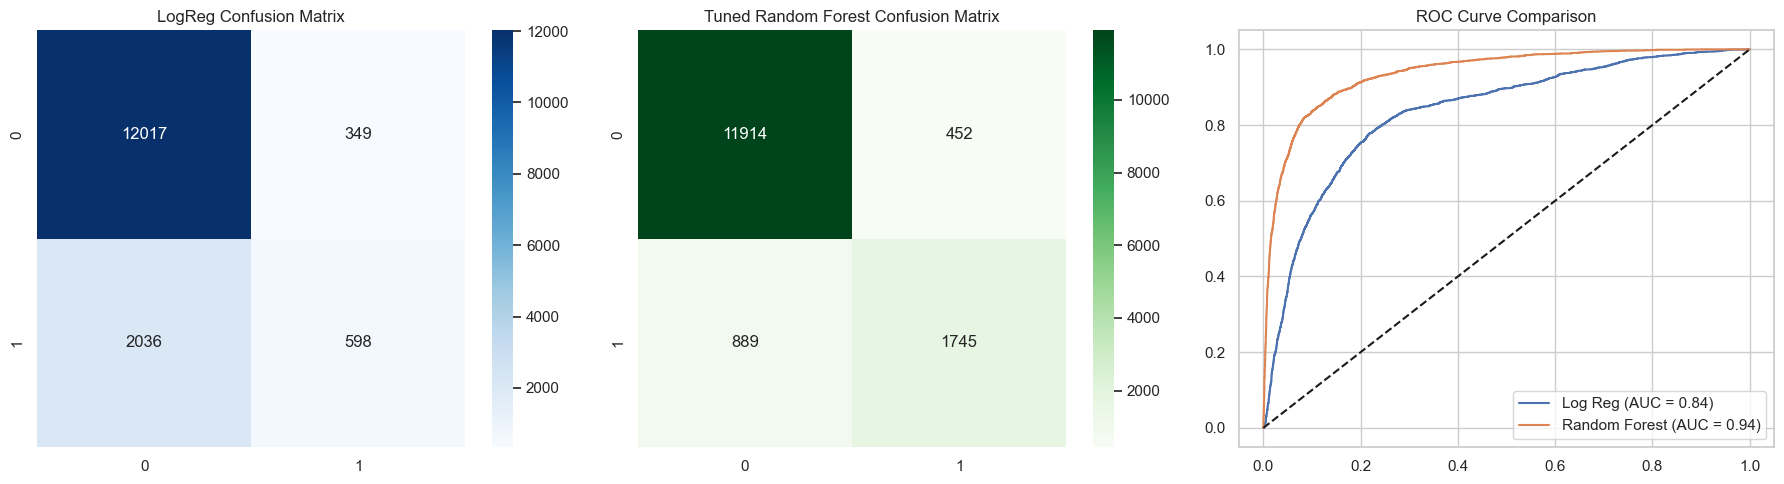

In [206]:
# ===========================================================
# STEP 4.4: VISUAL EVALUATION
# ===========================================================
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions here so this cell is 100% self-contained
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# 2. Visual Evaluation
plt.figure(figsize=(18, 5))

# Plot 1: Logistic Regression Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('LogReg Confusion Matrix')

# Plot 2: Random Forest Confusion Matrix
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Tuned Random Forest Confusion Matrix')

# Plot 3: ROC Curve Comparison
plt.subplot(1, 3, 3)
plt.plot(fpr_lr, tpr_lr, label=f'Log Reg (AUC = {auc(fpr_lr, tpr_lr):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# PHASE 5: INTERPRETATION AND REPORTING

### O. Model Performance Comparison
The **Tuned Random Forest Ensemble significantly outperformed the Logistic Regression** across all critical risk metrics, particularly after performing **Stratified Cross-Validation.**

* **Accuracy vs. Complexity:** The Random Forest achieved superior accuracy by capturing the non-linear relationships between economic conditions and loan outcomes that the linear Logistic Regression missed.

* **Predicting Defaults (Recall):** In credit risk, missing a default (False Negative) is far more expensive than declining a good loan. While Logistic Regression struggled with a Recall of 0.23, the Tuned Random Forest successfully captured 66% of all defaults (Recall: 0.66). By explicitly tuning the model for Recall, we have prioritized the bank's capital preservation.

### P. Most Important Features Influencing Credit Risk
Based on the model results, selected features, and observed data patterns, the primary factors associated with commercial loan default risk include:

* **Guarantee Percentage:** This engineered feature remains the strongest predictor. Higher SBA guarantees remain the strongest safety net for lenders.
* **Monthly Time-Aware Unemployment:** Precise **monthly alignment** with FRED data showed that local unemployment at the exact month of approval is a major leading indicator of default.
* **Loan Amount (GrAppv):** We utilized the **Requested Amount (GrAppv)** rather than post-disbursement fields to ensure the model supports real-time decision-making without data leakage.
* **Job Creation & Business Age:** Features like `CreateJob` and `NewExist` (startups vs. established) provide vital context regarding the business's growth stage and stability -> In other words, Startups were confirmed to be higher risk than established firms.
 

### Q. Model Usage in the Loan Approval Process
The Random Forest pipeline serves as a professional **Decision Support System**:

* **Automated Triage:** Applications with high 'Repay' probabilities can be fast-tracked for instant approval, while high-risk flags are routed to senior credit officers for manual review.
* **Risk-Based Structuring:** Loan officers can use the model for `What-If` tests, adjusting terms or guarantees to see if a risky loan can be made safe for approval.

### RI. Potential Limitations
* **Concept Drift:** Historical patterns can lose predictive power during extreme economic shocks (Example: high inflation or pandemics), requiring a continuous retraining pipeline to remain relevant.
* **Geographic Aggregation:** Using state-level macro data ignores local city-level economics and industry-specific health, which may reduce accuracy for niche business sectors.
* **Class Imbalance:** Because defaults are rare (~20% of cases), the model requires constant monitoring of "False Repay" biases to protect bank capital.

### RII. Areas for Improvement:
* **Encoding High-Cardinality Features:** Future versions should utilize Target Encoding to safely incorporate `City`, `Zip`, and `Bank` data without crashing the model or causing over-fitting.
* **Advanced Boosting Models:** Transitioning from Random Forest to *XGBoost* or *LightGBM* could provide a more refined precision-recall curve for sharper risk thresholds.
* **Expanded Macro Indicators:** Integrating "approval-time" sources like the **Consumer Price Index (CPI)** or **Federal interest rate spreads** would significantly strengthen the multi-source predictive argument.